# Nama : Firaz Afifudin
# NIM : 221351051

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [31]:
df = pd.read_csv('heart.csv')

In [32]:
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,55,High,High,Yes,Low,Overweight,High
1,43,Normal,Normal,No,Moderate,Normal,Low
2,60,High,High,Yes,Low,Obese,High
3,35,Normal,Low,No,High,Normal,Low
4,50,High,High,No,Low,Overweight,Medium


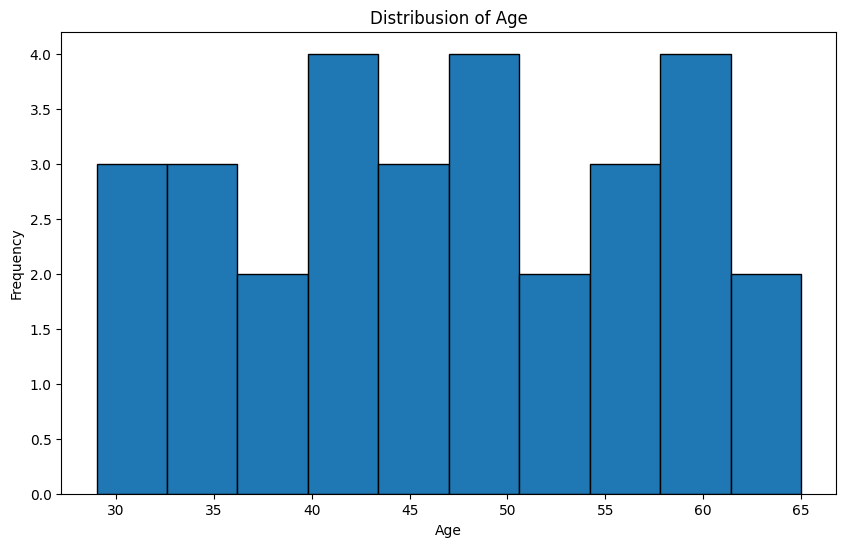

In [33]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=10, edgecolor= 'black')
plt.title ('Distribusion of Age')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

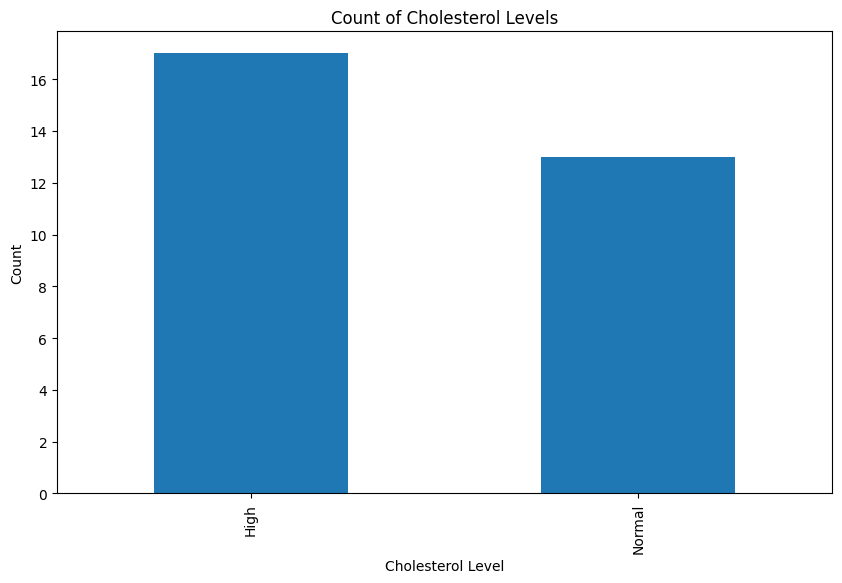

In [34]:
plt.figure(figsize=(10, 6))
df['Cholesterol Level'].value_counts().plot(kind='bar')
plt.title("Count of Cholesterol Levels")
plt.xlabel("Cholesterol Level")
plt.ylabel("Count")
plt.show()

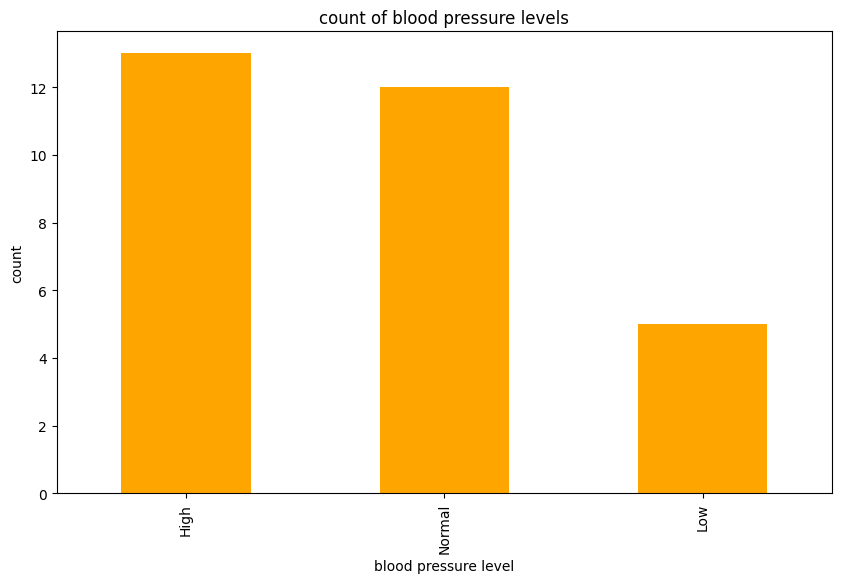

In [35]:
plt.figure(figsize=(10, 6))
df['Blood Pressure'].value_counts().plot(kind='bar', color='orange')
plt.title("count of blood pressure levels")
plt.xlabel("blood pressure level")
plt.ylabel("count")
plt.show()

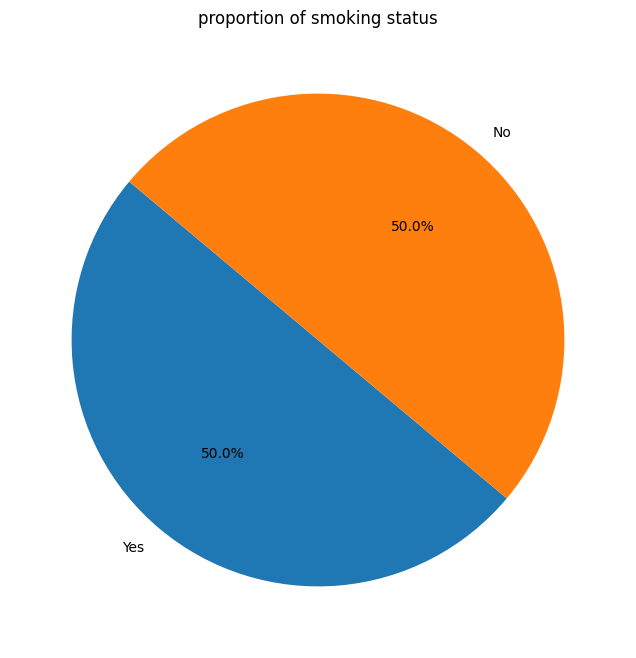

In [36]:
plt.figure(figsize=(8, 8))
df['Smoking'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("proportion of smoking status")
plt.ylabel("")
plt.show()

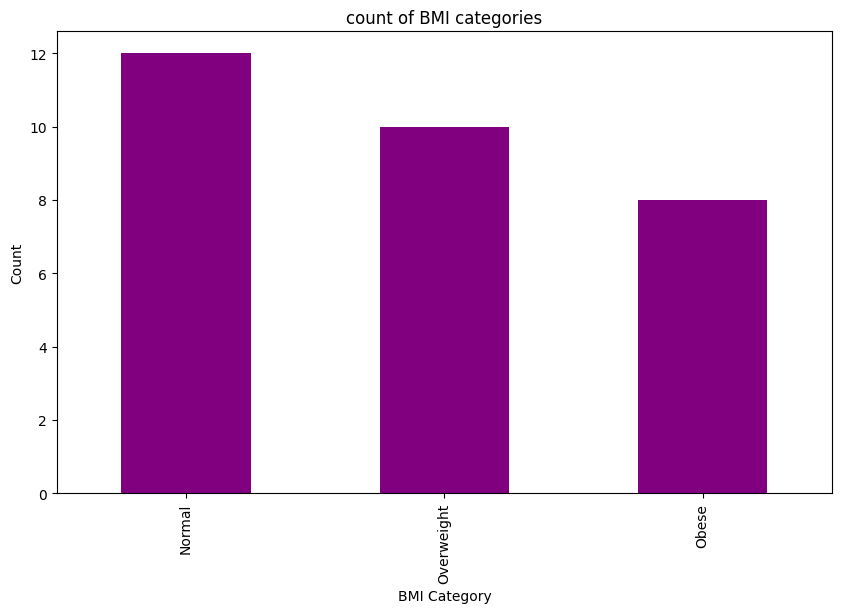

In [37]:
plt.figure(figsize=(10, 6))
df['BMI'].value_counts().plot(kind='bar', color='purple')
plt.title("count of BMI categories")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

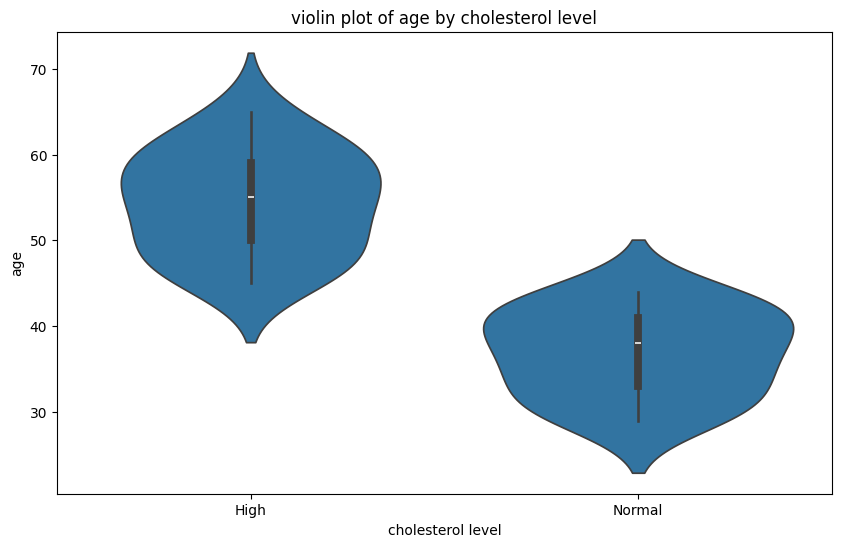

In [38]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Cholesterol Level', y='Age', data=df)
plt.title("violin plot of age by cholesterol level")
plt.xlabel("cholesterol level")
plt.ylabel("age")
plt.show()

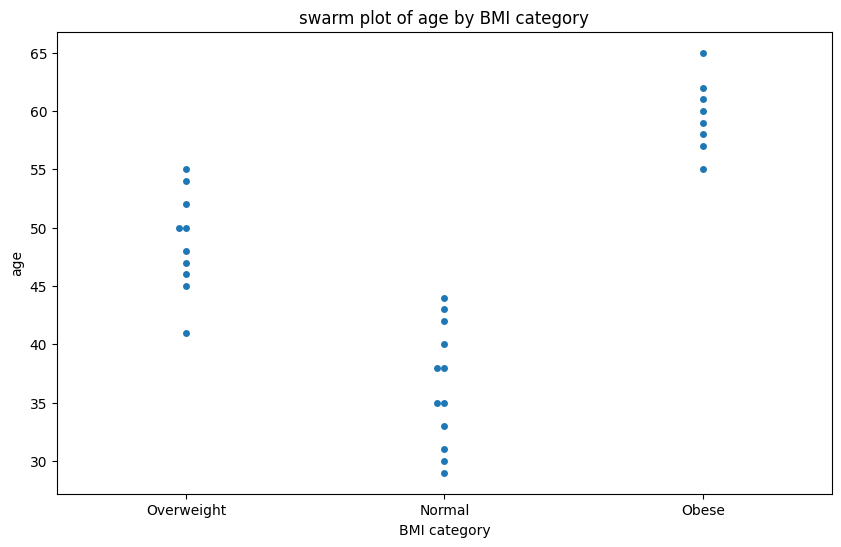

In [39]:
plt.figure(figsize=(10, 6))
sns.swarmplot(x='BMI', y='Age', data=df)
plt.title("swarm plot of age by BMI category")
plt.xlabel("BMI category")
plt.ylabel("age")
plt.show()

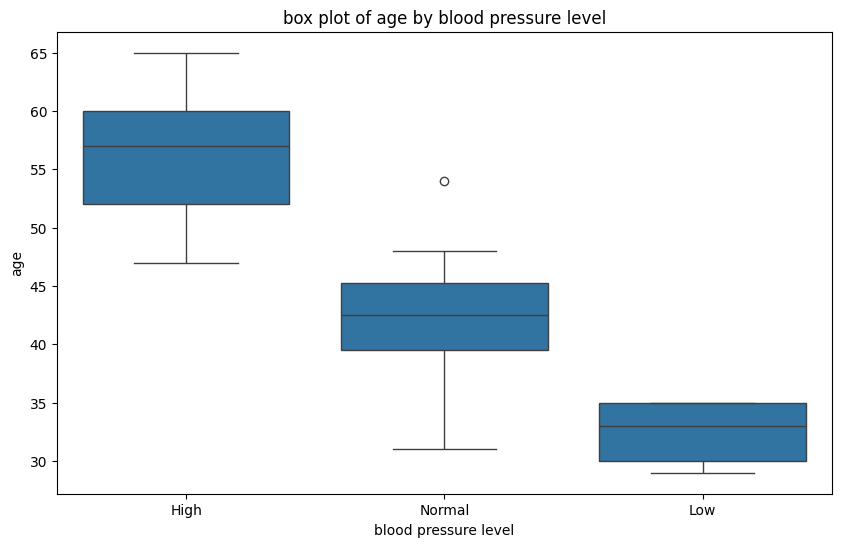

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Blood Pressure', y='Age', data=df)
plt.title("box plot of age by blood pressure level")
plt.xlabel("blood pressure level")
plt.ylabel("age")
plt.show()

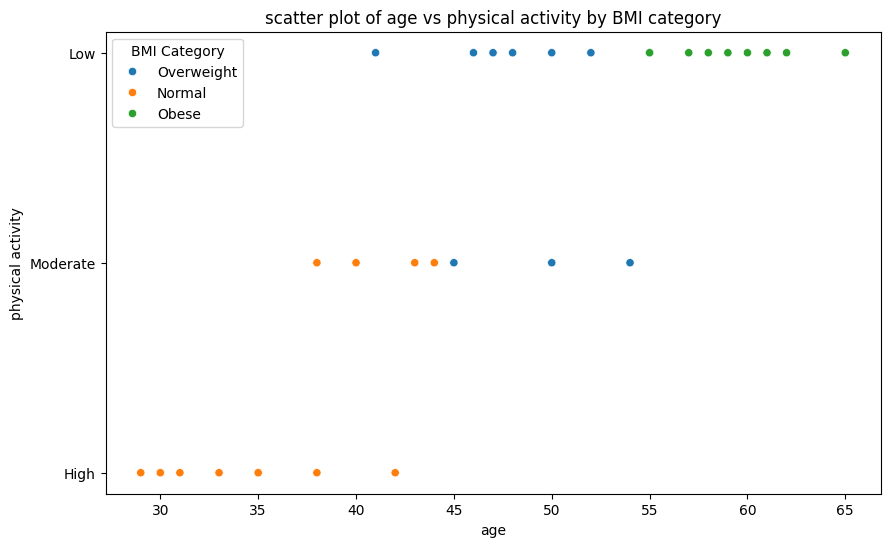

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Physical Activity', hue='BMI')
plt.title("scatter plot of age vs physical activity by BMI category")
plt.xlabel("age")
plt.ylabel("physical activity")
plt.legend(title="BMI Category")
plt.show()

In [42]:
def categorize_age(age):
    if age < 35:
        return "young"
    elif age < 55:
        return "midle-aged"
    else:
        return "senior"

In [43]:
df['Age'] = df['Age'].apply(categorize_age)

In [44]:
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,senior,High,High,Yes,Low,Overweight,High
1,midle-aged,Normal,Normal,No,Moderate,Normal,Low
2,senior,High,High,Yes,Low,Obese,High
3,midle-aged,Normal,Low,No,High,Normal,Low
4,midle-aged,High,High,No,Low,Overweight,Medium


In [45]:
label_encoders = {}
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le

In [46]:
df.head()

,Age,Cholesterol Level,Blood Pressure,Smoking,Physical Activity,BMI,Heart Disease Risk
0,1,0,0,1,1,2,0
1,0,1,2,0,2,0,1
2,1,0,0,1,1,1,0
3,0,1,1,0,0,0,1
4,0,0,0,0,1,2,2


In [47]:
X = df.drop('Heart Disease Risk', axis=1)
y = df['Heart Disease Risk']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [50]:
y_pred = model.predict(X_test)

In [51]:
new_data = pd.DataFrame({
    'Age': [label_encoders['Age'].transform(['midle-aged'])[0]],
    'Cholesterol Level': [label_encoders['Cholesterol Level'].transform(['High'])[0]],
    'Blood Pressure': [label_encoders['Blood Pressure'].transform(['High'])[0]],
    'Smoking': [label_encoders['Smoking'].transform(['Yes'])[0]],
    'Physical Activity': [label_encoders['Physical Activity'].transform(['Low'])[0]],
    'BMI': [label_encoders['BMI'].transform(['Overweight'])[0]]
})

In [52]:
new_prediction = model.predict(new_data)

In [53]:
new_prediction_decoded = label_encoders['Heart Disease Risk'].inverse_transform(new_prediction)

In [54]:
new_prediction_decoded

array(['High'], dtype=object)

In [55]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [56]:
accuracy, conf_matrix

(1.0,
 array([[3, 0, 0],
        [0, 5, 0],
        [0, 0, 1]]))

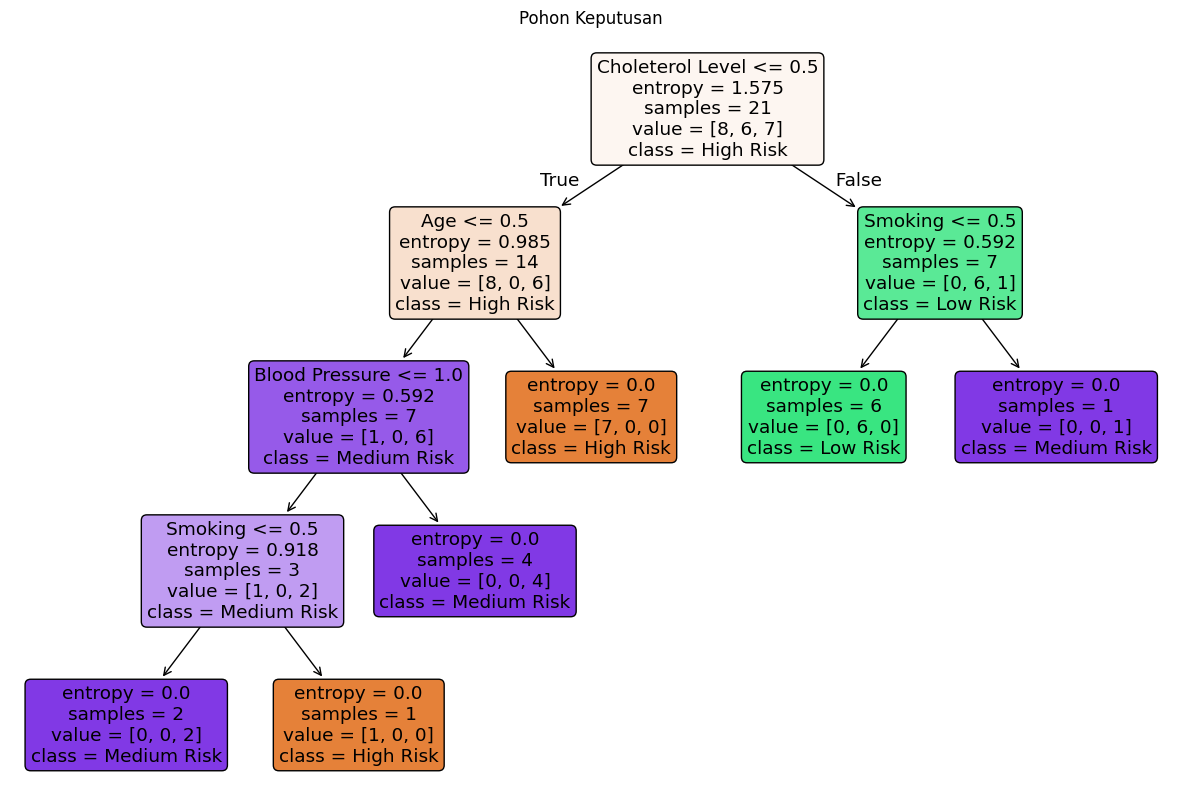

In [57]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=['Age',
                                'Choleterol Level',
                                'Blood Pressure',
                                'Smoking',
                                'Physical Activity',
                                'BMI'], class_names=['High Risk',
                                                     'Low Risk',
                                                     'Medium Risk'],
                                                      filled=True, rounded=True)
plt.title("Pohon Keputusan")
plt.show()